Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      124             91             98      552  34.7   
1           14      195            111             19      317  38.0   
2           10      125            118             60      501  20.9   
3            7       58             89             34      827  42.2   
4            6      123             72             49      380  22.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.370   76        0  
1                     1.270   50        1  
2                     0.308   77        1  
3                     1.659   50        1  
4                     2.064   67        1  


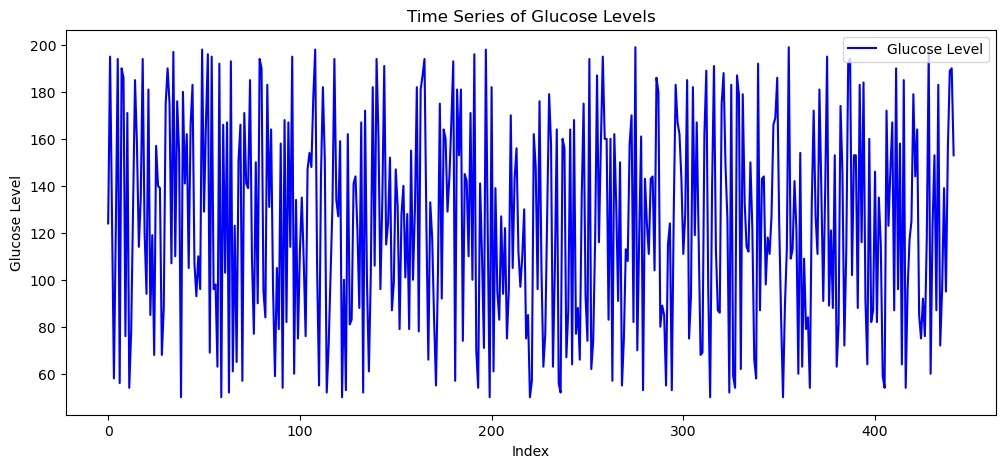

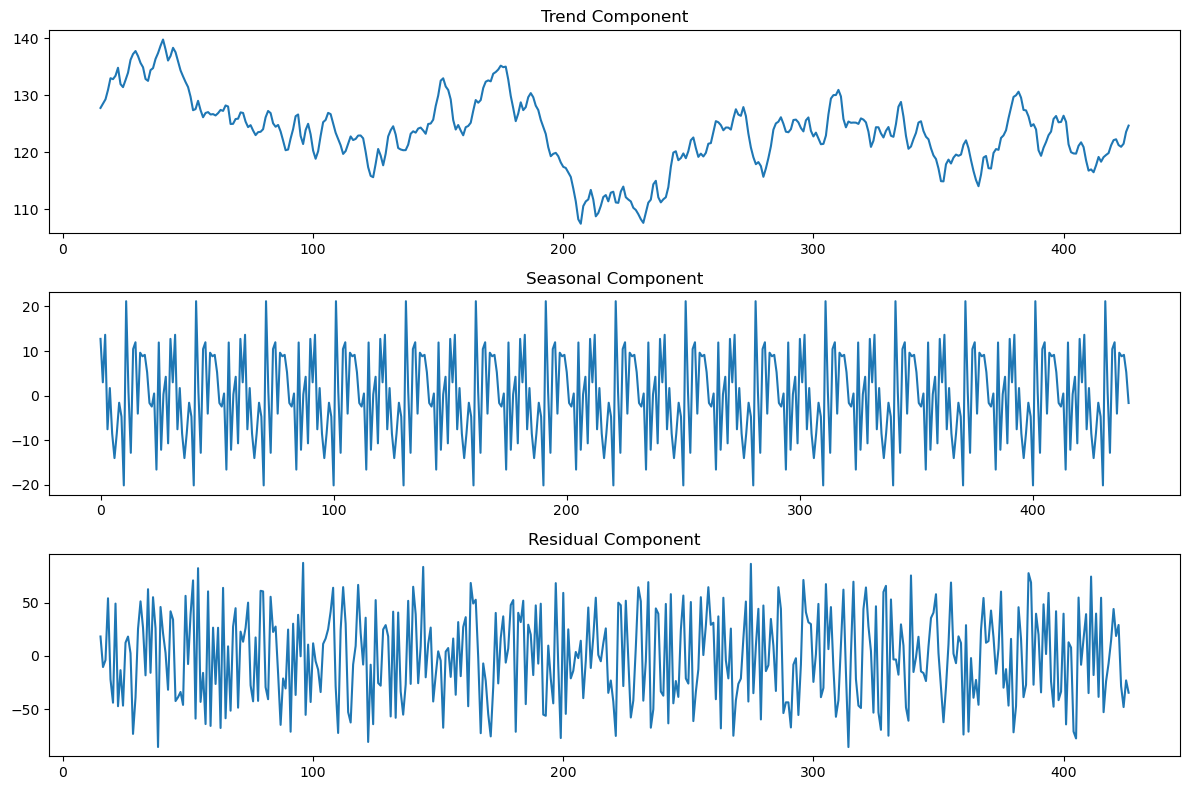

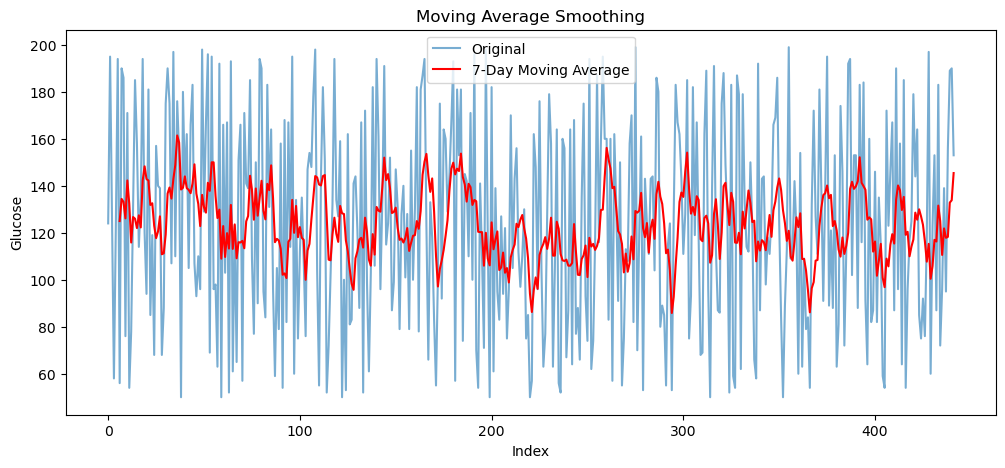

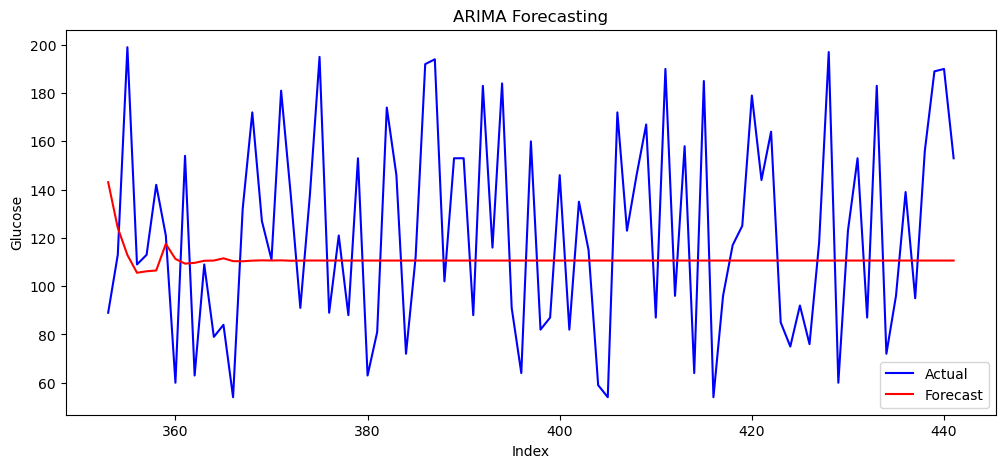

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Load Dataset
diabetes_data = pd.read_csv("uci_diabetes.csv")

# Display first few rows
print("Dataset Sample:")
print(diabetes_data.head())

# Plot Time Series Data
plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], color="blue", label="Glucose Level")
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

# Decompose Time Series
decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

# Plot Trend, Seasonality and Residuals
fig, axes = plt.subplots(3,1,figsize=(12,8))

decomposition.trend.plot(ax=axes[0])
axes[0].set_title("Trend Component")

decomposition.seasonal.plot(ax=axes[1])
axes[1].set_title("Seasonal Component")

decomposition.resid.plot(ax=axes[2])
axes[2].set_title("Residual Component")

plt.tight_layout()
plt.show()

# Moving Average Smoothing
diabetes_data["Glucose_MA"] = diabetes_data["Glucose"].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], label="Original", alpha=0.6)
plt.plot(diabetes_data["Glucose_MA"], label="7-Day Moving Average", color="red")
plt.title("Moving Average Smoothing")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.legend()
plt.show()

# Split Data into Training and Testing
train_size = int(len(diabetes_data) * 0.80)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

# Build ARIMA Model
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot Forecast
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual", color="blue")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.title("ARIMA Forecasting")
plt.legend()
plt.show()